In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [13]:
food = pd.read_csv("food_access_final.csv")
snap = pd.read_csv("snap.csv")

In [14]:
print(food.shape)
print(snap.shape)

food.head()
snap.head()

(72531, 150)
(703441, 15)


,Record ID,Store Name,Store Type,Street Number,Street Name,Additional Address,City,State,Zip Code,Zip4,County,Latitude,Longitude,Authorization Date,End Date
0,785740,ADAK GENERAL STORE,Convenience Store,42311,FINGER BAY RD,,ADAK,AK,99546,2036,ALEUTIANS EAST,51.84434,-176.6284,5/8/2006,3/1/2016
1,512036,Alaska Commercial Company 325,Combination Grocery/Other,1,BAYVIEW DR,,KING COVE,AK,99612,,ALEUTIANS EAST,55.05876,-162.3134,2/2/1999,
2,758776,Alaska Commercial Company 220,Combination Grocery/Other,100,Main St,NaN,Sand Point,AK,99661,9800,ALEUTIANS EAST,55.29988,-160.6714,7/5/2005,
3,309052,ALEUTIAN COMMERCIAL CO INC,Large Grocery Store,100,MAIN ST,,SAND POINT,AK,99661,,ALEUTIANS EAST,55.30257,-160.4045,7/28/1993,7/11/2005
4,737262,BEARFOOT INN ALASKA,Medium Grocery Store,123,BEAR COUNTRY RD,,COLD BAY,AK,99571,123,ALEUTIANS EAST,0.00000,0.0000,2/8/2005,3/28/2005


In [20]:
wv = food[food["State"] == "West Virginia"].copy()

In [21]:
print(wv.shape)
wv.head()

(484, 150)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP,AreaType,FoodDesert,VehicleAccess
70524,54001965500,West Virginia,Barbour County,0,3979,1555,0,0.0,0.000000,0,...,1.0,1.0,10.0,46.0,32.0,73.0,206.0,Rural,Not Food Desert,Has Vehicle
70525,54001965600,West Virginia,Barbour County,1,3564,1431,0,402.0,11.279461,1,...,28.0,1.0,50.0,103.0,22.0,232.0,340.0,Urban,Food Desert,Has Vehicle
70526,54001965700,West Virginia,Barbour County,0,5276,2090,0,0.0,0.000000,0,...,3.0,0.0,28.0,87.0,19.0,209.0,327.0,Rural,Not Food Desert,No Vehicle
70527,54001965800,West Virginia,Barbour County,0,3770,1472,0,67.0,1.777188,0,...,2.0,1.0,8.0,37.0,23.0,160.0,262.0,Rural,Not Food Desert,No Vehicle
70528,54003971101,West Virginia,Berkeley County,1,4614,1763,0,49.0,1.061985,0,...,61.0,0.0,7.0,220.0,180.0,34.0,180.0,Urban,Not Food Desert,Has Vehicle


In [22]:
wv[["VehicleAccess", "FoodDesert"]].head()

,VehicleAccess,FoodDesert
70524,Has Vehicle,Not Food Desert
70525,Has Vehicle,Food Desert
70526,No Vehicle,Not Food Desert
70527,No Vehicle,Not Food Desert
70528,Has Vehicle,Not Food Desert


In [24]:
wv["VehicleBinary"] = wv["VehicleAccess"].map({
    "No Vehicle": 0,
    "Has Vehicle": 1
})

In [25]:
wv_county = wv.groupby("County").agg({
    "Pop2010": "sum",
    "TractSNAP": "mean",
    "VehicleBinary": "mean"
}).reset_index()

In [26]:
wv_county.head()

,County,Pop2010,TractSNAP,VehicleBinary
0,Barbour County,16589,283.750000,0.500000
1,Berkeley County,104169,389.000000,0.785714
2,Boone County,24629,305.000000,0.250000
3,Braxton County,14523,390.333333,0.000000
4,Brooke County,24069,215.166667,0.500000


In [29]:
wv["FoodDesert"].unique()

array(['Not Food Desert', 'Food Desert'], dtype=object)

In [31]:
wv["FoodDesertBinary"] = wv["FoodDesert"].map({
    "Food Desert": 1,
    "Not Food Desert": 0
})

In [32]:
wv_county = wv.groupby("County").agg({
    "Pop2010": "sum",
    "TractSNAP": "mean",
    "VehicleBinary": "mean",
    "FoodDesertBinary": "mean"
}).reset_index()

In [33]:
top10 = wv_county.sort_values(
    "FoodDesertBinary",
    ascending=False
).head(10)

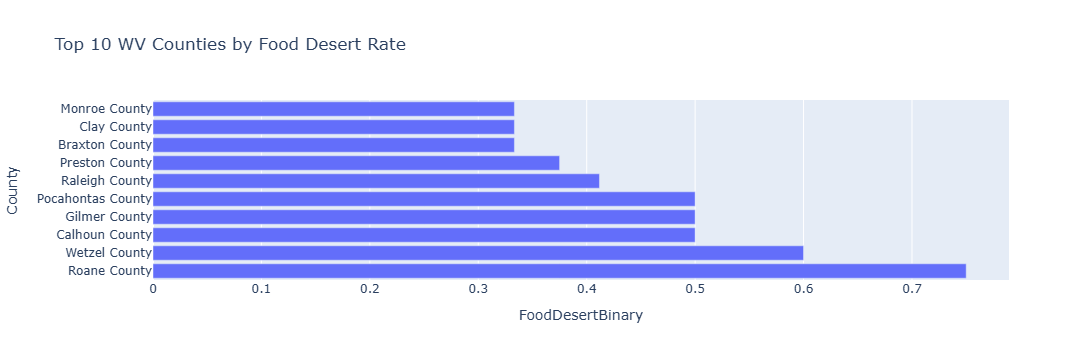

In [34]:
fig = px.bar(
    top10,
    x="FoodDesertBinary",
    y="County",
    orientation="h",
    title="Top 10 WV Counties by Food Desert Rate"
)

fig.show()

In [37]:
wv_county = wv.groupby("County").agg({
    "Pop2010": "sum",
    "PovertyRate": "mean",
    "lasnaphalfshare": "mean",
    "lahunvhalfshare": "mean",
    "lapophalfshare": "mean"
}).reset_index()

# RENAME COLUMNS FOR READABILITY
wv_county.columns = [
    "County",
    "Population",
    "PovertyRate",
    "SNAP_LowAccess",
    "NoVehicle_LowAccess",
    "LowAccessRate"
]

# VIEW DATA
print(wv_county.head())

            County  Population  PovertyRate  SNAP_LowAccess  \
0   Barbour County       16589    23.722279       15.861815   
1  Berkeley County      104169    13.879936       10.094790   
2     Boone County       24629    23.691184       24.345332   
3   Braxton County       14523    21.519758       19.738906   
4    Brooke County       24069    13.568952       10.635079   

   NoVehicle_LowAccess  LowAccessRate  
0             7.638397      92.354765  
1             3.209386      83.159010  
2            11.458732      91.699270  
3             9.066608      93.115623  
4             6.244253      88.443951  


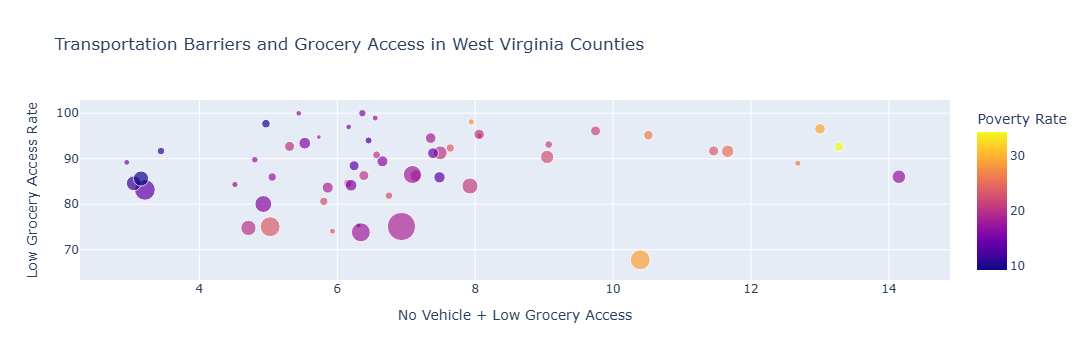

In [38]:
fig = px.scatter(
    wv_county,
    x="NoVehicle_LowAccess",
    y="LowAccessRate",
    size="Population",
    hover_name="County",
    color="PovertyRate",
    title="Transportation Barriers and Grocery Access in West Virginia Counties",
    labels={
        "NoVehicle_LowAccess": "No Vehicle + Low Grocery Access",
        "LowAccessRate": "Low Grocery Access Rate",
        "PovertyRate": "Poverty Rate"
    }
)

fig.show()

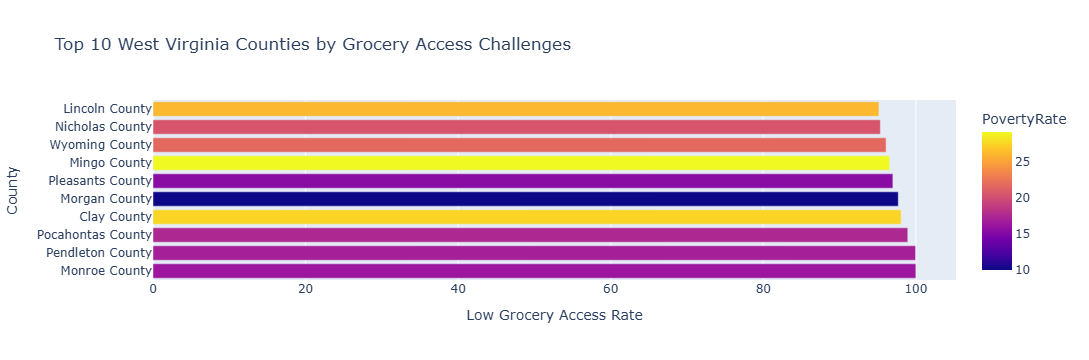

In [39]:
top10 = wv_county.sort_values(
    "LowAccessRate",
    ascending=False
).head(10)

fig = px.bar(
    top10,
    x="LowAccessRate",
    y="County",
    orientation="h",
    color="PovertyRate",
    title="Top 10 West Virginia Counties by Grocery Access Challenges",
    labels={
        "LowAccessRate": "Low Grocery Access Rate"
    }
)

fig.show()


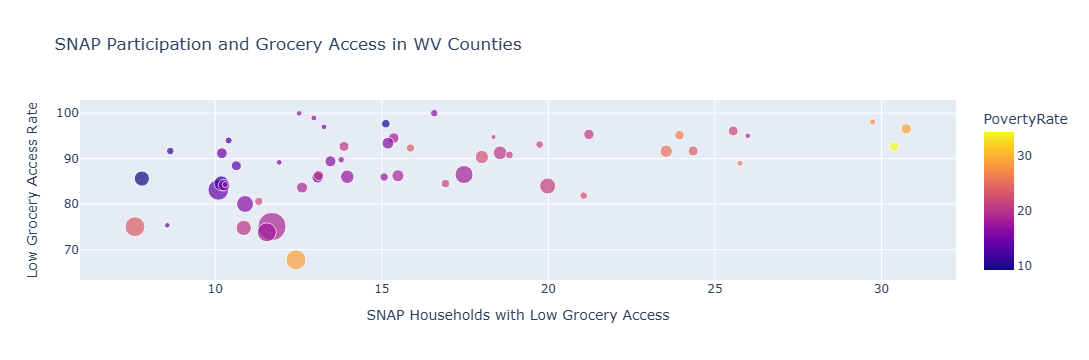

In [40]:
fig = px.scatter(
    wv_county,
    x="SNAP_LowAccess",
    y="LowAccessRate",
    size="Population",
    hover_name="County",
    color="PovertyRate",
    title="SNAP Participation and Grocery Access in WV Counties",
    labels={
        "SNAP_LowAccess": "SNAP Households with Low Grocery Access",
        "LowAccessRate": "Low Grocery Access Rate"
    }
)

fig.show()


In [41]:
wv_county.to_csv("wv_county_summary.csv", index=False)

In [45]:
high_need = wv_county[
    wv_county["LowAccessRate"] > wv_county["LowAccessRate"].mean()
]

print(high_need)

               County  Population  PovertyRate  SNAP_LowAccess  \
0      Barbour County       16589    23.722279       15.861815   
2        Boone County       24629    23.691184       24.345332   
3      Braxton County       14523    21.519758       19.738906   
4       Brooke County       24069    13.568952       10.635079   
6      Calhoun County        7627    18.565781       25.985529   
7         Clay County        9386    27.514170       29.734344   
8    Doddridge County        8202    15.712233       11.922216   
9      Fayette County       46039    20.365699       18.552693   
11       Grant County       11937    12.121356       10.404759   
13   Hampshire County       23964    20.057045       13.867064   
15       Hardy County       14025    10.925892        8.652819   
17     Jackson County       29211    16.404790       13.461388   
21     Lincoln County       21720    26.141279       23.936457   
22       Logan County       36743    25.231163       23.537478   
25       M

C:\Users\Student\AppData\Local\Temp\ipykernel_12072\3538195398.py:11: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



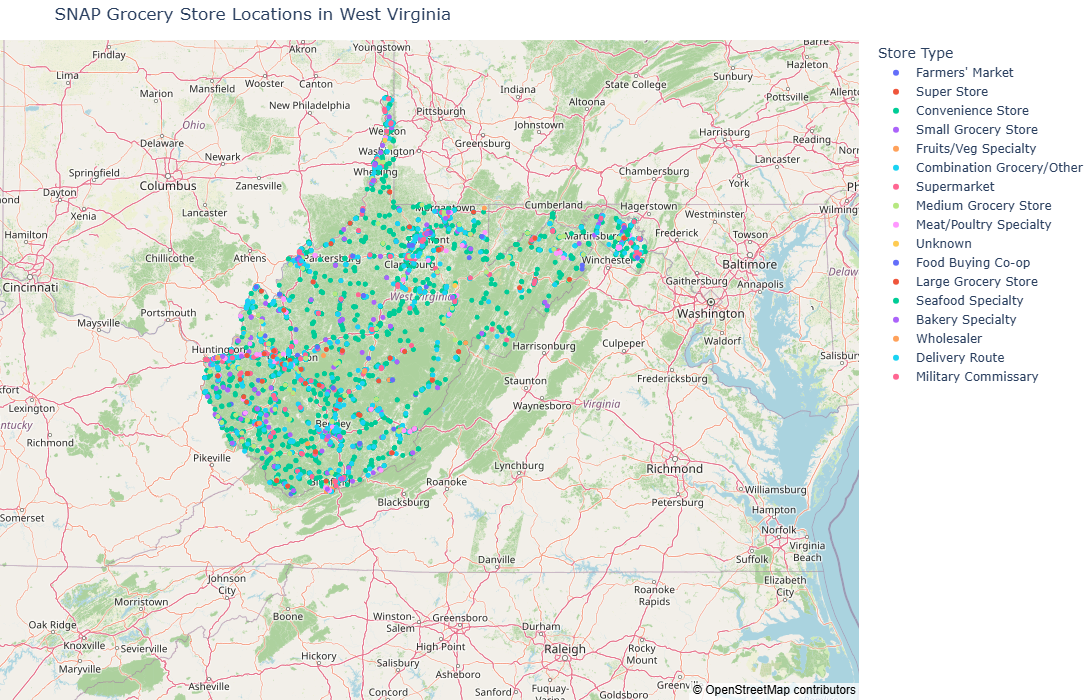

In [46]:
import pandas as pd
import plotly.express as px

# LOAD STORE DATA
stores = pd.read_csv("snap.csv")

# FILTER TO WEST VIRGINIA
wv_snap = stores[stores["State"] == "WV"].copy()

# CREATE MAP
fig = px.scatter_mapbox(
    wv_snap,
    lat="Latitude",
    lon="Longitude",
    color="Store Type",
    hover_name="Store Name",
    hover_data=["City", "County"],
    zoom=6,
    height=700,
    title="SNAP Grocery Store Locations in West Virginia"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

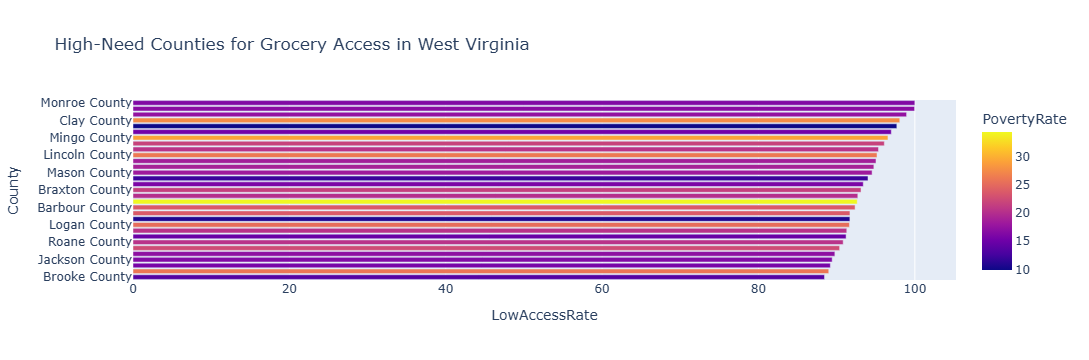

In [47]:
fig = px.bar(
    high_need.sort_values("LowAccessRate"),
    x="LowAccessRate",
    y="County",
    orientation="h",
    color="PovertyRate",
    title="High-Need Counties for Grocery Access in West Virginia"
)

fig.show()

In [49]:
wv_county = wv.groupby("County").agg({
    "lapophalfshare": "mean"
}).reset_index()

# RENAME COLUMN
wv_county.columns = [
    "County",
    "low_access_rate"
]

# TOP 5 WORST COUNTIES
top5 = wv_county.sort_values(
    "low_access_rate",
    ascending=False
).head(5)

print(top5)

               County  low_access_rate
31      Monroe County       100.000000
35   Pendleton County        99.963383
37  Pocahontas County        98.943844
7         Clay County        98.071894
32      Morgan County        97.696454


In [50]:
print(snap.columns)

Index(['Record ID', 'Store Name', 'Store Type', 'Street Number', 'Street Name',
       'Additional Address', 'City', 'State', 'Zip Code', 'Zip4', 'County',
       'Latitude', 'Longitude', 'Authorization Date', 'End Date'],
      dtype='object')


In [51]:
store_counts = snap.groupby(
    ["County", "Store Type"]
).size().reset_index(name="Count")

In [52]:
store_pivot = store_counts.pivot(
    index="County",
    columns="Store Type",
    values="Count"
).fillna(0).reset_index()

In [53]:
top5_stores = top5.merge(
    store_pivot,
    on="County",
    how="left"
)

In [54]:
store_cols = [
    "Farmers Market",
    "Full Grocery Access",
    "Limited Access",
    "Other"
]

In [57]:
print(top5_stores.columns.tolist())

['County', 'low_access_rate', 'Bakery Specialty', 'Combination Grocery/Other', 'Convenience Store', 'Delivery Route', "Farmers' Market", 'Food Buying Co-op', 'Fruits/Veg Specialty', 'Large Grocery Store', 'Meat/Poultry Specialty', 'Medium Grocery Store', 'Military Commissary', 'Seafood Specialty', 'Small Grocery Store', 'Super Store', 'Supermarket', 'Unknown', 'Wholesaler']
